# E-Energy Plotting

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set the style of the plots
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=1.2)

## Motivation LMP Knee Plot

/var/folders/3j/5n1r8yyx2d58jn87prrxs_lm0000gn/T/ipykernel_91535/1321847323.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cloud_csv_filter["dispatch_diff_norm"] = cloud_csv_filter["dispatch_diff"]*100.0 / 2244.6224861202586


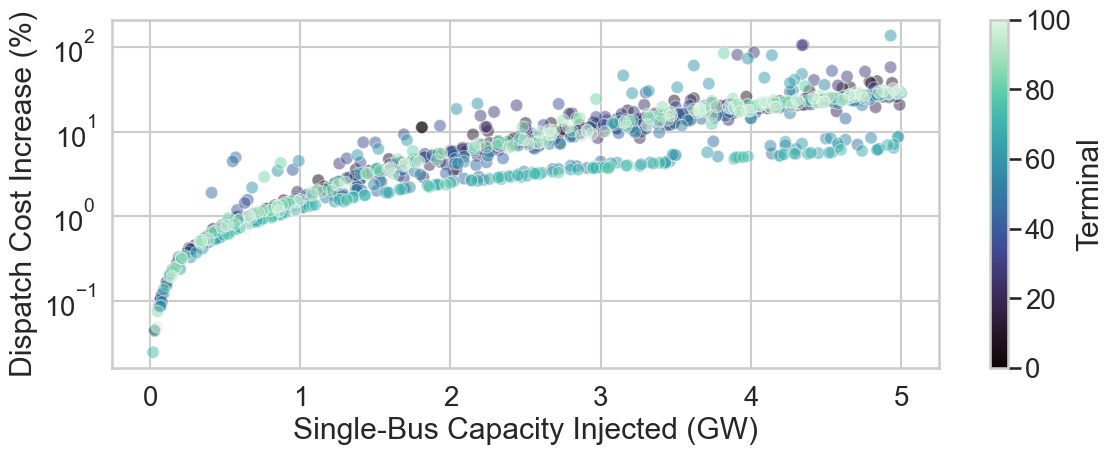

In [4]:
cloud_csv = pd.read_csv("cloud_congestion.csv")
terminal_land_cost_mapping = pd.read_csv("terminal_land_cost_mapping.csv")

cloud_csv = cloud_csv.merge(terminal_land_cost_mapping, on="terminal", how="left")
cloud_csv_filter = cloud_csv[cloud_csv["land_usd2017_per_acre"] < 1e9]
cloud_csv_filter["dispatch_diff_norm"] = cloud_csv_filter["dispatch_diff"]*100.0 / 2244.6224861202586

plt.figure(figsize=(12,5))
scatter = sns.scatterplot(
    data=cloud_csv_filter, 
    x="capacity (GW)", 
    y="dispatch_diff_norm", 
    hue="terminal", 
    palette="mako", 
    legend=False,
    alpha=0.5
)
norm = plt.Normalize(cloud_csv_filter["terminal"].min(), cloud_csv_filter["terminal"].max())
sm = plt.cm.ScalarMappable(cmap="mako", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Terminal")
plt.xlabel("Single-Bus Capacity Injected (GW)")
plt.ylabel("Dispatch Cost Increase (%)")
# plt.ylim(1e-1,1e1)
# plt.ylim(-5, 150)
plt.yscale("log")
plt.tight_layout()
plt.savefig("dispatch_cost_percent_increase.pdf", bbox_inches="tight")

/var/folders/3j/5n1r8yyx2d58jn87prrxs_lm0000gn/T/ipykernel_91535/2309310861.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cloud_csv_filter["sys_max_lmp_norm"] = (cloud_csv_filter["sys_max_lmp"] - 0.7369661651734399) * 100.0 / 0.7369661651734399


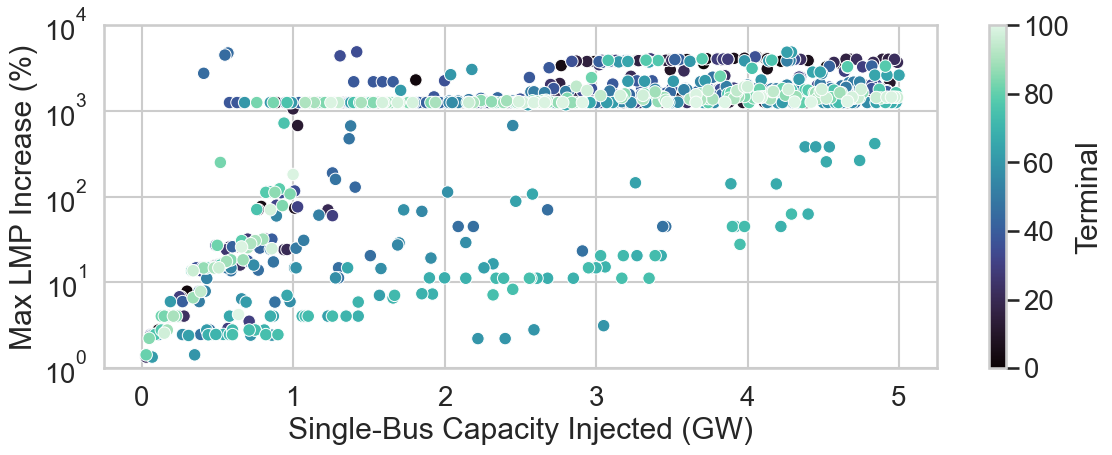

In [5]:
plt.figure(figsize=(12,5))
cloud_csv_filter["sys_max_lmp_norm"] = (cloud_csv_filter["sys_max_lmp"] - 0.7369661651734399) * 100.0 / 0.7369661651734399
nodes = [32, 82, 50, 18, 15, 22, 43, 14, 23, 20, 94, 65, 78]

scatter = sns.scatterplot(
    data=cloud_csv_filter, 
    x="capacity (GW)", 
    y="sys_max_lmp_norm", 
    hue="terminal", 
    palette="mako", 
    legend=False
)
norm = plt.Normalize(cloud_csv_filter["terminal"].min(), cloud_csv_filter["terminal"].max())
sm = plt.cm.ScalarMappable(cmap="mako", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Terminal")
plt.xlabel("Single-Bus Capacity Injected (GW)")
plt.ylabel("Max LMP Increase (%)")
plt.ylim(1e0,1e4)
# plt.xlim(0,7)
# plt.ylim(-100,5000)
plt.yscale("log")
plt.tight_layout()
plt.savefig("max_lmp_increase.pdf", bbox_inches="tight")

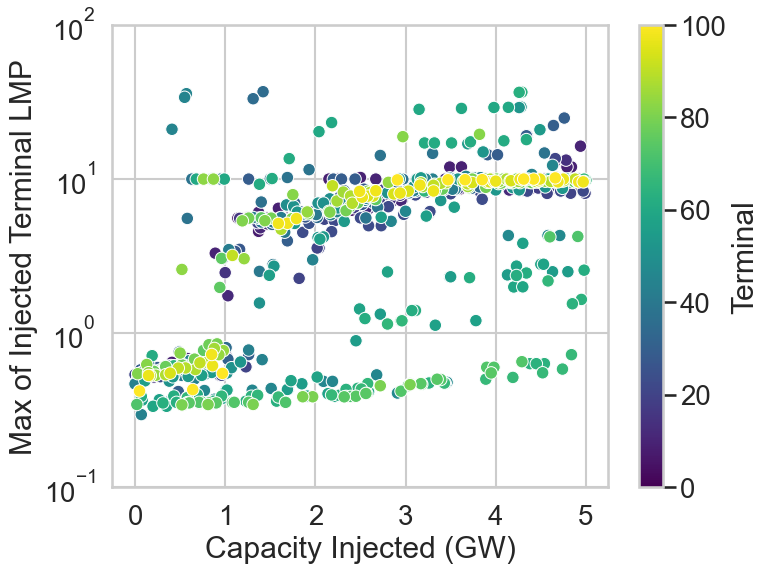

In [64]:
plt.figure(figsize=(8,6))
scatter = sns.scatterplot(
    data=cloud_csv_filter, 
    x="capacity (GW)", 
    y="inj_max_lmp", 
    hue="terminal", 
    palette="viridis", 
    legend=False
)
norm = plt.Normalize(cloud_csv_filter["terminal"].min(), cloud_csv_filter["terminal"].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca())
cbar.set_label("Terminal")
plt.xlabel("Capacity Injected (GW)")
plt.ylabel("Max of Injected Terminal LMP")
plt.ylim(1e-1,1e2)
plt.yscale("log")
plt.show()

/var/folders/3j/5n1r8yyx2d58jn87prrxs_lm0000gn/T/ipykernel_67905/3421490769.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cloud_csv_filter["sys_max_lmp_norm"] = (cloud_csv_filter["sys_max_lmp"] - base) * 100.0 / base
/var/folders/3j/5n1r8yyx2d58jn87prrxs_lm0000gn/T/ipykernel_67905/3421490769.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cloud_csv_filter["terminal_group"] = cloud_csv_filter["terminal"].map(
/var/folders/3j/5n1r8yyx2d58jn87prrxs_lm0000gn/T/ipykernel_67905/3421490769.py:17: Settin

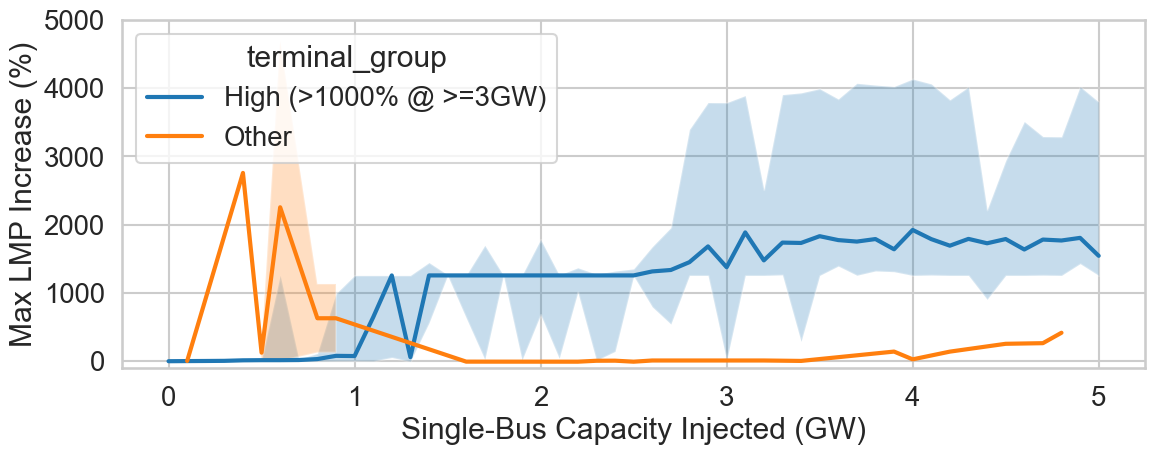

In [185]:
base = 0.7369661651734399
cloud_csv_filter["sys_max_lmp_norm"] = (cloud_csv_filter["sys_max_lmp"] - base) * 100.0 / base

# --- bifurcate terminals: "high" if ANY point with capacity >= 3 GW has LMP increase > 1000% ---
term_is_high = (
    cloud_csv_filter.loc[cloud_csv_filter["capacity (GW)"] >= 1.0]
      .groupby("terminal")["sys_max_lmp_norm"]
      .max()
      .gt(1000)
)

cloud_csv_filter["terminal_group"] = cloud_csv_filter["terminal"].map(
    lambda t: "High (>1000% @ >=3GW)" if term_is_high.get(t, False) else "Other"
)

bin_w = 0.10  # GW bin width (try 0.05, 0.1, 0.2)
cloud_csv_filter["cap_bin"] = (cloud_csv_filter["capacity (GW)"] / bin_w).round() * bin_w

# --- aggregate within each bin & group ---
g = (
    cloud_csv_filter.groupby(["terminal_group", "cap_bin"])["sys_max_lmp_norm"]
      .agg(
          med="median",
          lo=lambda s: s.quantile(0.10),   # heavy band: 10–90%
          hi=lambda s: s.quantile(0.90),
      )
      .reset_index()
      .sort_values("cap_bin")
)

plt.figure(figsize=(12,5))

# line: median
sns.lineplot(
    data=g, x="cap_bin", y="med", hue="terminal_group",
    linewidth=3
)

# shaded band: 10–90%
ax = plt.gca()
for name, sub in g.groupby("terminal_group"):
    ax.fill_between(sub["cap_bin"], sub["lo"], sub["hi"], alpha=0.25)

ax.set_xlabel("Single-Bus Capacity Injected (GW)")
ax.set_ylabel("Max LMP Increase (%)")
ax.set_ylim(-100, 5000)
plt.tight_layout()